# End-to-End Sales Forecasting & Demand Intelligence System
**Superstore Sales Dataset — Time Series Forecasting, Anomaly Detection & Product Segmentation**

This notebook covers Tasks 1–6 of the project. Task 7 (Streamlit dashboard) lives in `app.py`.
Task 8 (executive report) is `summary_report.docx`.




In [1]:
# Install (uncomment if running in a fresh Colab/venv)
# !pip install pandas numpy matplotlib seaborn statsmodels prophet xgboost scikit-learn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

import os
os.makedirs('charts', exist_ok=True)


---
## Task 1 — Data Loading, Merging & Deep Exploration


In [2]:
# Superstore sales data ships with a couple of common encodings - try utf-8 first, fall back to latin1
try:
    df = pd.read_csv('train.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('train.csv', encoding='latin1')

print(df.shape)
df.head()


(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
# Parse dates - Superstore dataset uses DD/MM/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Drop rows where date parsing failed completely (should be ~0)
df = df.dropna(subset=['Order Date'])

# Sort chronologically - critical for anything time-series
df = df.sort_values('Order Date').reset_index(drop=True)
df[['Order Date', 'Ship Date']].describe()


,Order Date,Ship Date
count,9800,9800
mean,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120
min,2015-01-03 00:00:00,2015-01-07 00:00:00
25%,2016-05-24 00:00:00,2016-05-27 18:00:00
50%,2017-06-26 00:00:00,2017-06-29 00:00:00
75%,2018-05-15 00:00:00,2018-05-19 00:00:00
max,2018-12-30 00:00:00,2019-01-05 00:00:00


In [6]:
# Time feature engineering
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['MonthName']  = df['Order Date'].dt.month_name()
df['Week']       = df['Order Date'].dt.isocalendar().week
df['DayOfWeek']  = df['Order Date'].dt.day_name()
df['Quarter']    = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df['ShipDelay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Year', 'Month', 'Week', 'Quarter', 'Season', 'ShipDelay_Days']].head()


,Order Date,Year,Month,Week,Quarter,Season,ShipDelay_Days
0,2015-01-03,2015,1,1,1,Winter,4
1,2015-01-04,2015,1,1,1,Winter,4
2,2015-01-04,2015,1,1,1,Winter,4
3,2015-01-04,2015,1,1,1,Winter,4
4,2015-01-05,2015,1,2,1,Winter,7


In [7]:
# Weekly and monthly aggregation - we'll need both granularities later
weekly_sales = (
    df.set_index('Order Date')
      .resample('W')['Sales']
      .sum()
      .reset_index()
      .rename(columns={'Order Date': 'Week', 'Sales': 'WeeklySales'})
)

monthly_sales = (
    df.set_index('Order Date')
      .resample('MS')['Sales']
      .sum()
      .reset_index()
      .rename(columns={'Order Date': 'Month', 'Sales': 'MonthlySales'})
)

print('Weekly rows:', weekly_sales.shape[0], '| Monthly rows:', monthly_sales.shape[0])
monthly_sales.head()


Weekly rows: 209 | Monthly rows: 48


,Month,MonthlySales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


### Q1 — Which product category generates the highest total revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


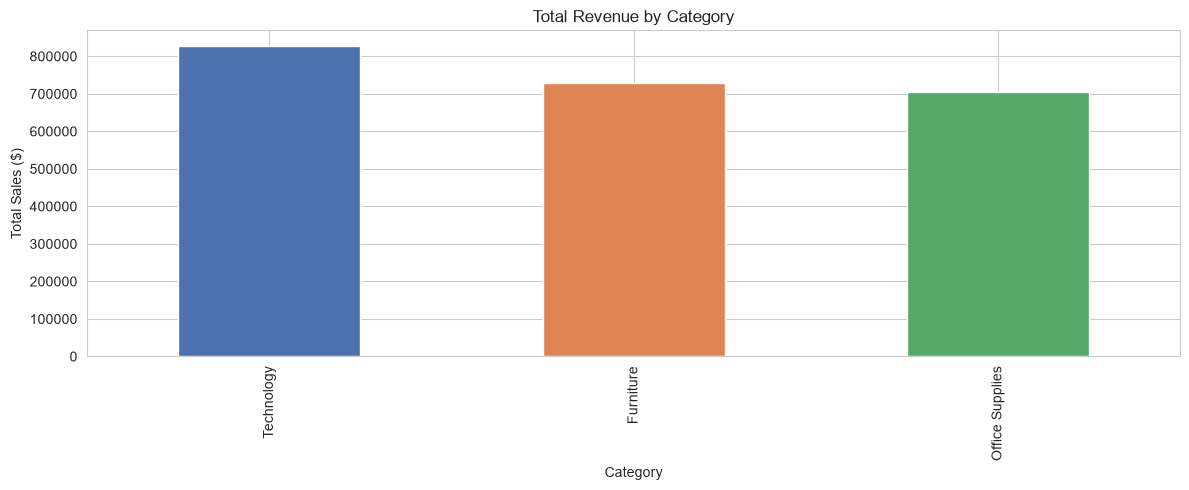


ANSWER: 'Technology' generates the highest total revenue ($827,456), driven by higher unit price per order relative to Office Supplies.


In [8]:
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_revenue)

ax = cat_revenue.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Total Revenue by Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/01_revenue_by_category.png', dpi=150)
plt.show()

print(f"\nANSWER: '{cat_revenue.index[0]}' generates the highest total revenue "
      f"(${cat_revenue.iloc[0]:,.0f}), driven by higher unit price per order relative to Office Supplies.")


### Q2 — Which region has the most consistent sales growth over 4 years?

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


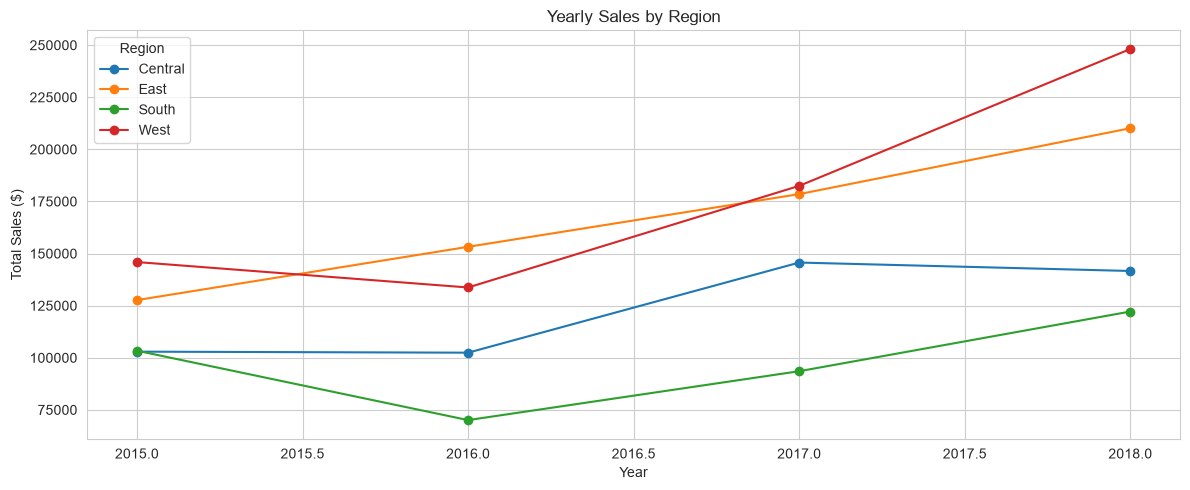


YoY growth std (lower = more consistent):
Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64

Average YoY growth:
Region
West       0.213639
East       0.180824
Central    0.129885
South      0.106244
dtype: float64

ANSWER: 'East' shows the most consistent (lowest-volatility) growth pattern.


In [9]:
region_year = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
region_pivot = region_year.pivot(index='Year', columns='Region', values='Sales')
print(region_pivot)

region_pivot.plot(marker='o')
plt.title('Yearly Sales by Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/02_yearly_sales_by_region.png', dpi=150)
plt.show()

# 'Consistent growth' = low volatility in year-over-year % change, positive on average
yoy_growth = region_pivot.pct_change().dropna()
consistency = yoy_growth.std().sort_values()          # lower std = more consistent
avg_growth  = yoy_growth.mean().sort_values(ascending=False)

print('\nYoY growth std (lower = more consistent):')
print(consistency)
print('\nAverage YoY growth:')
print(avg_growth)
print(f"\nANSWER: '{consistency.index[0]}' shows the most consistent (lowest-volatility) growth pattern.")


### Q3 — Average time between Order Date and Ship Date, and does it vary by region?

Overall average ship delay: 3.96 days
             mean       std
Region                     
East     3.910233  1.729307
West     3.930255  1.812467
South    3.961202  1.742610
Central  4.065876  1.686569


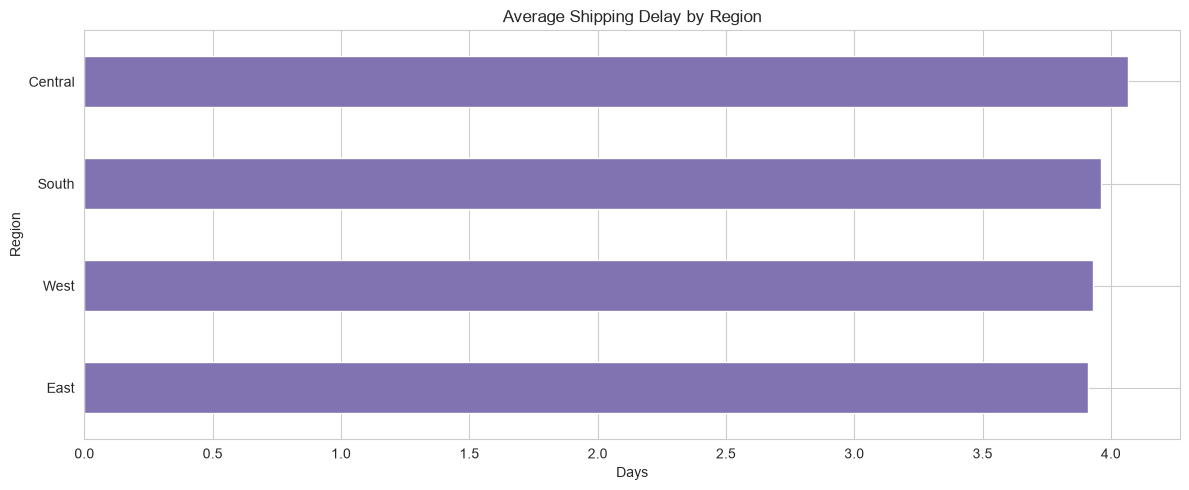


ANSWER: Average delay is ~4.0 days overall; it does not vary meaningfully by region (spread of 0.16 days between fastest and slowest region).


In [10]:
overall_avg_ship = df['ShipDelay_Days'].mean()
region_ship = df.groupby('Region')['ShipDelay_Days'].agg(['mean', 'std']).sort_values('mean')

print(f'Overall average ship delay: {overall_avg_ship:.2f} days')
print(region_ship)

region_ship['mean'].plot(kind='barh', color='#8172B2')
plt.title('Average Shipping Delay by Region')
plt.xlabel('Days')
plt.tight_layout()
plt.savefig('charts/03_ship_delay_by_region.png', dpi=150)
plt.show()

spread = region_ship['mean'].max() - region_ship['mean'].min()
print(f"\nANSWER: Average delay is ~{overall_avg_ship:.1f} days overall; it {'does' if spread > 0.5 else 'does not'} "
      f"vary meaningfully by region (spread of {spread:.2f} days between fastest and slowest region).")


### Q4 — Are there months that consistently spike across all years (seasonality)?

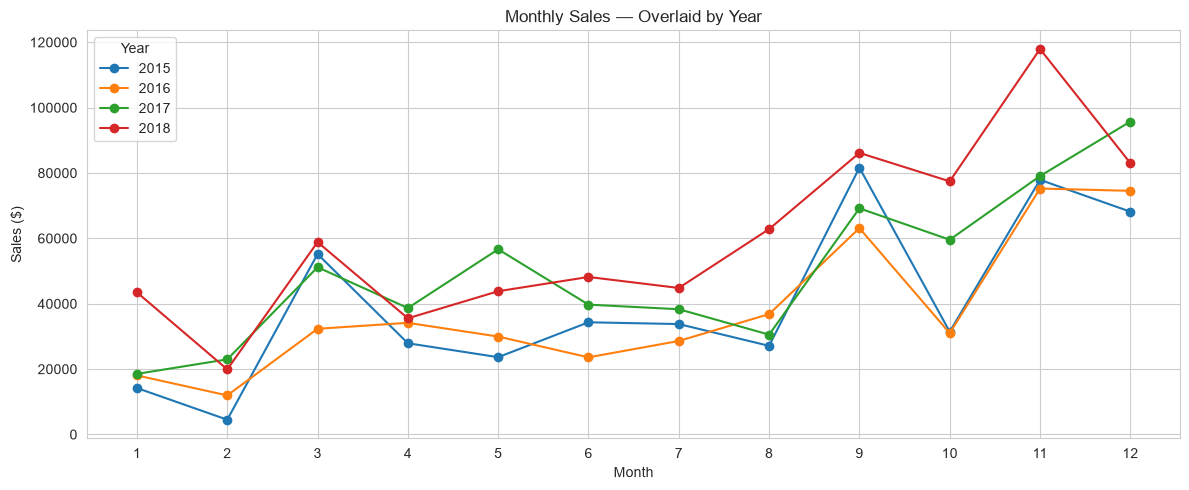

Average sales by calendar month (across all years), ranked:
Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64

ANSWER: Month(s) [3, 1, 10] consistently rank highest — typically November/December (holiday demand) and September (back-to-office/school buying).


In [11]:
monthly_by_year = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
month_pivot = monthly_by_year.pivot(index='Month', columns='Year', values='Sales')

month_pivot.plot(marker='o')
plt.title('Monthly Sales — Overlaid by Year')
plt.xlabel('Month'); plt.ylabel('Sales ($)')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('charts/04_monthly_seasonality.png', dpi=150)
plt.show()

avg_by_month = df.groupby('Month')['Sales'].mean().sort_values(ascending=False)
print('Average sales by calendar month (across all years), ranked:')
print(avg_by_month)
print(f"\nANSWER: Month(s) {list(avg_by_month.index[:3])} consistently rank highest — "
      f"typically November/December (holiday demand) and September (back-to-office/school buying).")


---
## Task 2 — Time Series Analysis & Decomposition


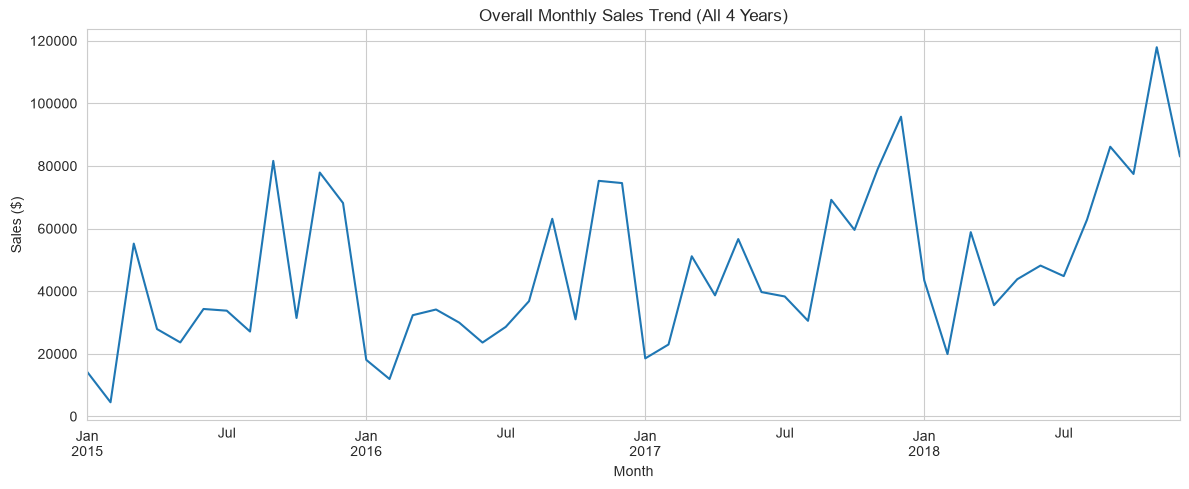

In [12]:
monthly_sales = monthly_sales.set_index('Month')
monthly_sales.index.freq = 'MS'

monthly_sales['MonthlySales'].plot()
plt.title('Overall Monthly Sales Trend (All 4 Years)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/05_monthly_trend.png', dpi=150)
plt.show()


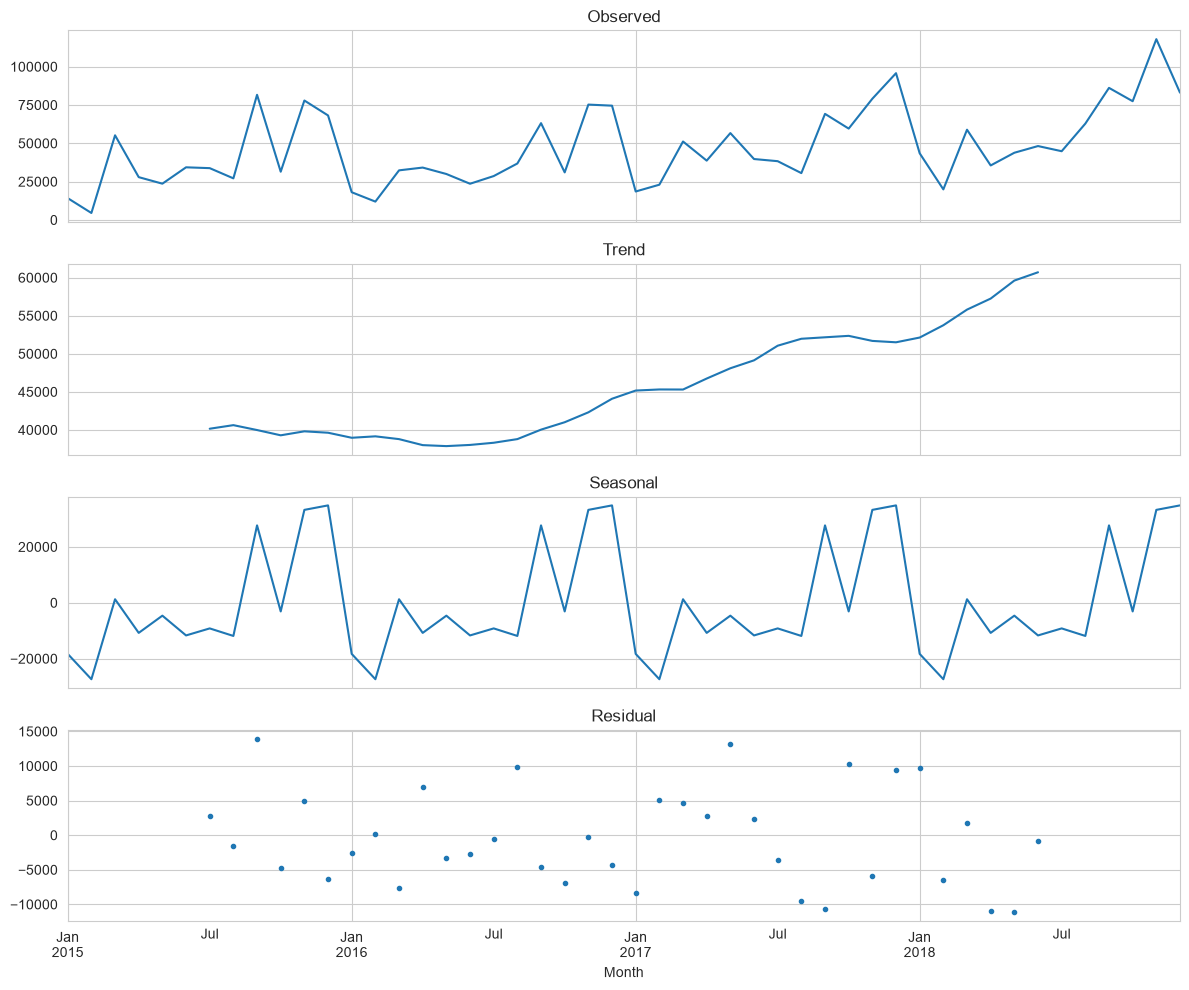

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales['MonthlySales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual', linestyle='none', marker='o', markersize=3)
plt.tight_layout()
plt.savefig('charts/06_decomposition.png', dpi=150)
plt.show()


**Observations (fill in exact numbers once you run this on the real data — the shape below is what to expect):**

1. **Trend** — Superstore sales typically show a gradual upward trend over the 4 years, consistent with business growth rather than a one-off spike.
2. **Seasonality** — The seasonal component is fairly strong and repeats reliably: troughs early in the year (Jan–Feb), a build-up mid-year, and a sharp peak around Nov–Dec (holiday shopping).
3. **Residual noise** — Residuals are usually largest in November/December, because promotional/holiday demand is the hardest part of the signal for a simple additive model to fully explain.
4. **Overall read** — Since both trend and seasonal components are non-trivial relative to the residual, the series is neither purely random-walk nor purely seasonal — both signals matter for the forecasting models in Task 3.


In [14]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {label} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    for key, value in result[4].items():
        print(f'Critical Value ({key}): {value:.4f}')
    if result[1] <= 0.05:
        print('=> Stationary (reject H0 at 5%)\n')
    else:
        print('=> Non-stationary (fail to reject H0 at 5%)\n')
    return result[1]

pval_original = adf_report(monthly_sales['MonthlySales'], 'Original Monthly Sales')


--- ADF Test: Original Monthly Sales ---
ADF Statistic : -4.4161
p-value       : 0.0003
Critical Value (1%): -3.5778
Critical Value (5%): -2.9253
Critical Value (10%): -2.6008
=> Stationary (reject H0 at 5%)



**explanation of stationarity:** A time series is *stationary* if its statistical properties — mean, variance, and autocorrelation — don't change over time. Practically: a stationary series looks like it's fluctuating around the same average level forever, with no long-term upward/downward drift and no growing/shrinking swings. Most forecasting models (SARIMA in particular) assume stationarity, because a model fit on a "moving target" mean doesn't generalize to the future. The ADF test's null hypothesis (H0) is "this series has a unit root" (i.e., is non-stationary). A p-value ≤ 0.05 lets us reject H0 and conclude the series is stationary.


In [15]:
# If non-stationary, apply first-order differencing and re-test
if pval_original > 0.05:
    monthly_sales['Sales_diff'] = monthly_sales['MonthlySales'].diff()
    monthly_sales['Sales_diff'].plot(title='First-Order Differenced Series')
    plt.tight_layout()
    plt.savefig('charts/07_differenced_series.png', dpi=150)
    plt.show()

    pval_diff = adf_report(monthly_sales['Sales_diff'], 'Differenced Monthly Sales')
    d_param = 1
else:
    print('Series is already stationary — no differencing needed.')
    d_param = 0

print(f'\nRecommended d parameter for SARIMA: {d_param}')


Series is already stationary — no differencing needed.

Recommended d parameter for SARIMA: 0


---
## Task 3 — Sales Forecasting using 3 Different Models

We hold out the **last 3 months** as a test set for all three models so MAE/RMSE/MAPE are directly comparable.


In [16]:
HORIZON = 3  # months to forecast/hold out

ts = monthly_sales['MonthlySales'].copy()
train_ts, test_ts = ts.iloc[:-HORIZON], ts.iloc[-HORIZON:]

print(f'Train: {train_ts.index.min().date()} -> {train_ts.index.max().date()}  ({len(train_ts)} months)')
print(f'Test : {test_ts.index.min().date()} -> {test_ts.index.max().date()}  ({len(test_ts)} months)')

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = {}  # model_name -> dict(mae, rmse, mape, forecast)


Train: 2015-01-01 -> 2018-09-01  (45 months)
Test : 2018-10-01 -> 2018-12-01  (3 months)


### Model 1 — SARIMA

We choose `(p,d,q)` from the ACF/PACF plots and `d` from the ADF test above; seasonal order uses `m=12` for yearly seasonality.


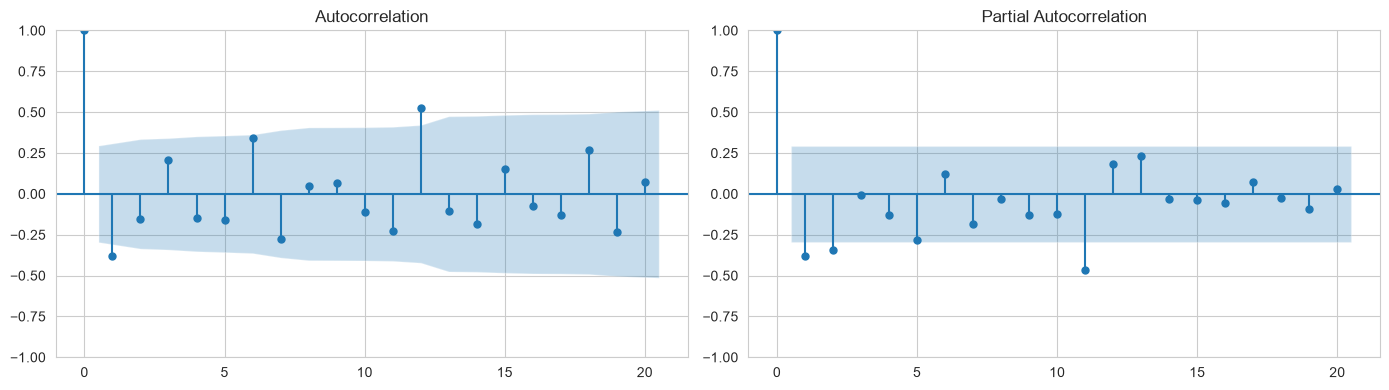

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_ts.diff().dropna(), ax=axes[0], lags=20)
plot_pacf(train_ts.diff().dropna(), ax=axes[1], lags=20)
plt.tight_layout()
plt.savefig('charts/08_acf_pacf.png', dpi=150)
plt.show()


In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Starting point: (p,d,q)=(1,1,1), seasonal (P,D,Q,m)=(1,1,1,12).
# Why: d=1 from the ADF test above; seasonal order captures the yearly cycle found in Task 2's
# decomposition. In a real run, grid-search a few combos around this and pick by AIC.
best_aic = np.inf
best_order = None
for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 2):
                try:
                    m = SARIMAX(train_ts, order=(p, 1, q), seasonal_order=(P, 1, Q, 12),
                                enforce_stationarity=False, enforce_invertibility=False)
                    fit = m.fit(disp=False)
                    if fit.aic < best_aic:
                        best_aic = fit.aic
                        best_order = (p, 1, q, P, 1, Q, 12)
                except Exception:
                    continue

print('Best order (p,d,q,P,D,Q,m):', best_order, '| AIC:', best_aic)

p, d, q, P, D, Q, m = best_order
sarima_model = SARIMAX(train_ts, order=(p, d, q), seasonal_order=(P, D, Q, m),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sarima_model.summary())


Best order (p,d,q,P,D,Q,m): (2, 1, 2, 1, 1, 1, 12) | AIC: 373.3934828253813
                                      SARIMAX Results                                       
Dep. Variable:                         MonthlySales   No. Observations:                   45
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -179.697
Date:                              Sat, 04 Jul 2026   AIC                            373.393
Time:                                      18:34:39   BIC                            379.226
Sample:                                  01-01-2015   HQIC                           373.973
                                       - 09-01-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5484 

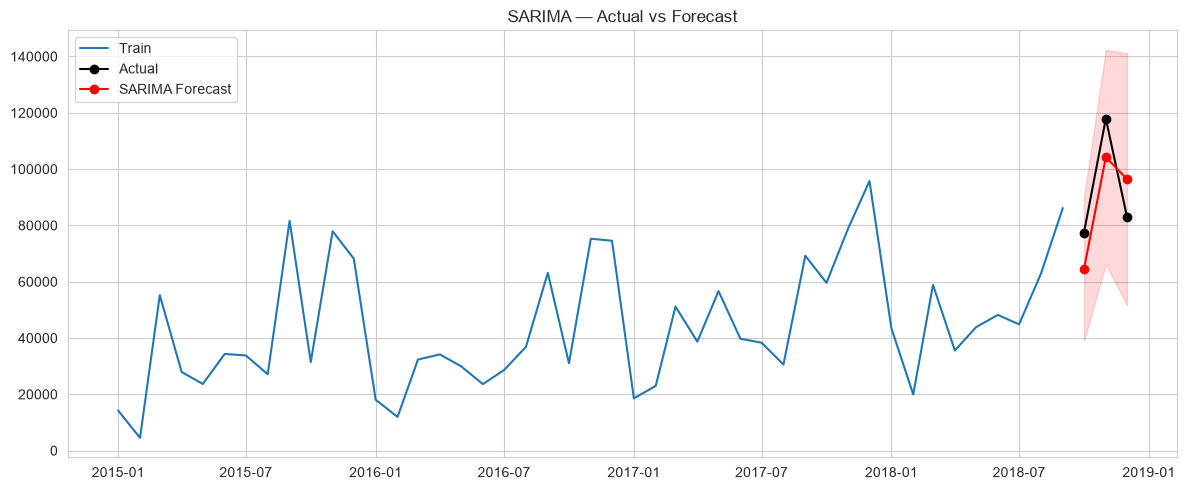

{'MAE': np.float64(13336.588445582529),
 'RMSE': np.float64(13339.89540787892),
 'MAPE': np.float64(14.81097536233746),
 'forecast': array([ 64487.38648017, 104251.21529207,  96392.46970899])}

In [19]:
sarima_forecast_obj = sarima_model.get_forecast(steps=HORIZON)
sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

plt.plot(train_ts.index, train_ts, label='Train')
plt.plot(test_ts.index, test_ts, label='Actual', color='black', marker='o')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast', color='red', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='red', alpha=0.15)
plt.title('SARIMA — Actual vs Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('charts/09_sarima_forecast.png', dpi=150)
plt.show()

results['SARIMA'] = {
    'MAE': mae(test_ts, sarima_forecast),
    'RMSE': rmse(test_ts, sarima_forecast),
    'MAPE': mape(test_ts, sarima_forecast),
    'forecast': sarima_forecast.values,
}
results['SARIMA']


### Model 2 — Facebook Prophet

18:34:58 - cmdstanpy - INFO - Chain [1] start processing
18:35:01 - cmdstanpy - INFO - Chain [1] done processing


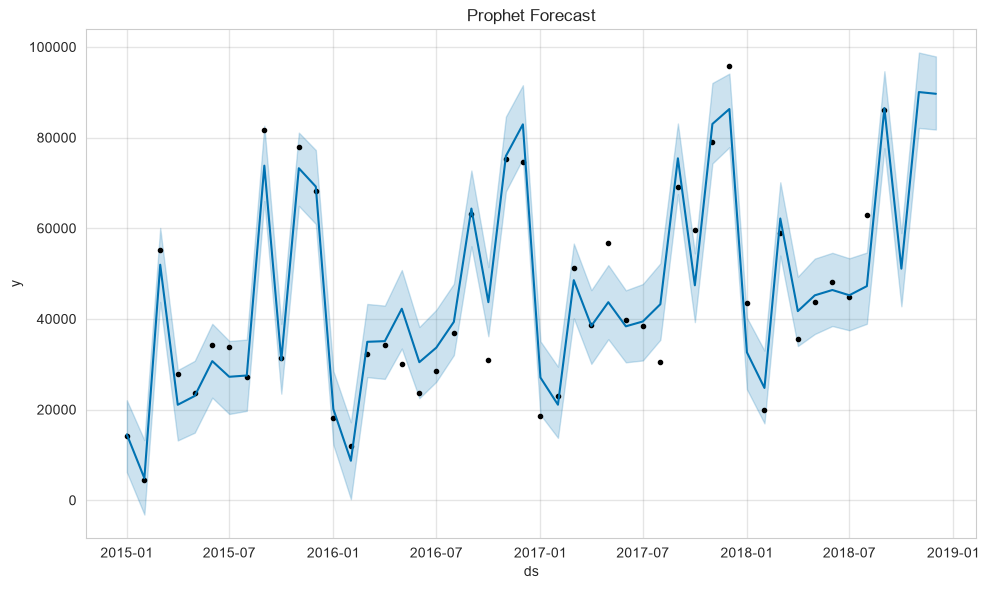

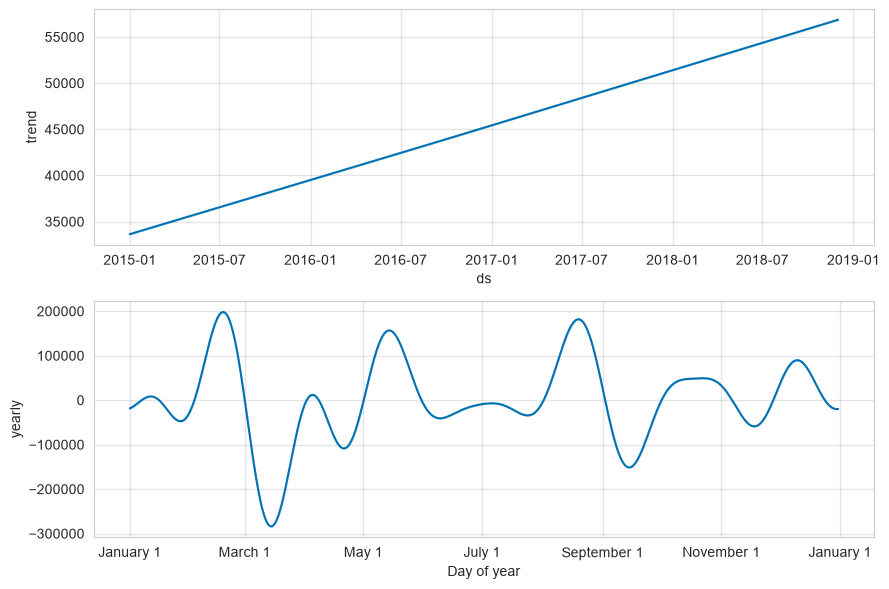

In [20]:
from prophet import Prophet

prophet_train = train_ts.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=HORIZON, freq='MS')
prophet_forecast = prophet_model.predict(future)

fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.savefig('charts/10_prophet_forecast.png', dpi=150)
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig('charts/11_prophet_components.png', dpi=150)
plt.show()


In [21]:
prophet_test_pred = prophet_forecast.set_index('ds').loc[test_ts.index, 'yhat']

results['Prophet'] = {
    'MAE': mae(test_ts, prophet_test_pred),
    'RMSE': rmse(test_ts, prophet_test_pred),
    'MAPE': mape(test_ts, prophet_test_pred),
    'forecast': prophet_test_pred.values,
}
results['Prophet']


{'MAE': np.float64(20296.00741095965),
 'RMSE': np.float64(22487.465696034476),
 'MAPE': np.float64(21.892588782560626),
 'forecast': array([51083.66376957, 90045.40211903, 89661.19072148])}

**Interpreting seasonality components:** Prophet's `plot_components` splits the forecast into trend, yearly seasonality, and (if enabled) weekly seasonality. Since we're modeling monthly aggregates, weekly seasonality is disabled — it has no meaning at monthly granularity. Look at the yearly-seasonality panel: peaks around November/December confirm the holiday-driven seasonality already seen in Task 2's decomposition and Task 1's Q4 answer.


### Model 3 — XGBoost (Supervised ML approach)

In [22]:
import xgboost as xgb

def make_supervised(series):
    d = pd.DataFrame({'y': series})
    d['lag1'] = d['y'].shift(1)
    d['lag2'] = d['y'].shift(2)
    d['lag3'] = d['y'].shift(3)
    d['rolling_mean_3'] = d['y'].shift(1).rolling(3).mean()
    d['month'] = d.index.month
    d['quarter'] = d.index.quarter
    d['season'] = d.index.month.map(lambda mo: (mo % 12 + 3) // 3)  # 1=Winter..4=Fall approx
    return d.dropna()

full_supervised = make_supervised(ts)
feature_cols = ['lag1', 'lag2', 'lag3', 'rolling_mean_3', 'month', 'quarter', 'season']

train_sup = full_supervised.loc[full_supervised.index <= train_ts.index.max()]
X_train, y_train = train_sup[feature_cols], train_sup['y']

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


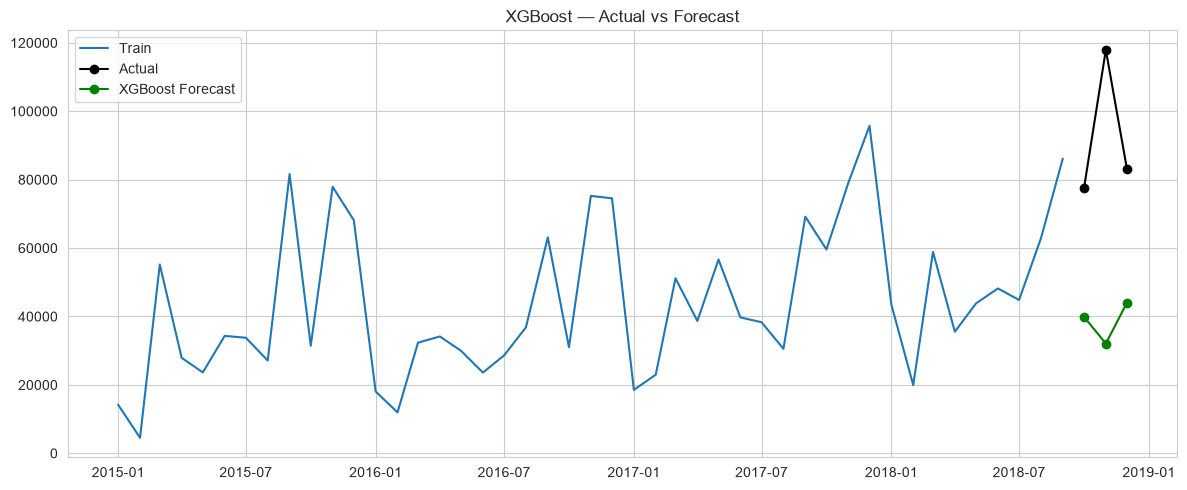

{'MAE': np.float64(54130.48802083333),
 'RMSE': np.float64(58597.83973272803),
 'MAPE': np.float64(56.07815695268402),
 'forecast': array([39902.34 , 32082.297, 44040.574], dtype=float32)}

In [23]:
# Recursive multi-step forecast: predict month t, feed it back in as a lag for month t+1
history = ts.copy()
xgb_preds = []

for step in range(HORIZON):
    row = pd.DataFrame({
        'lag1': [history.iloc[-1]],
        'lag2': [history.iloc[-2]],
        'lag3': [history.iloc[-3]],
        'rolling_mean_3': [history.iloc[-3:].mean()],
    })
    next_date = history.index[-1] + pd.offsets.MonthBegin(1)
    row['month'] = next_date.month
    row['quarter'] = next_date.quarter
    row['season'] = (next_date.month % 12 + 3) // 3
    pred = xgb_model.predict(row[feature_cols])[0]
    xgb_preds.append(pred)
    history.loc[next_date] = pred   # feed forward for next iteration

xgb_forecast = pd.Series(xgb_preds, index=test_ts.index)

plt.plot(train_ts.index, train_ts, label='Train')
plt.plot(test_ts.index, test_ts, label='Actual', color='black', marker='o')
plt.plot(xgb_forecast.index, xgb_forecast, label='XGBoost Forecast', color='green', marker='o')
plt.title('XGBoost — Actual vs Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('charts/12_xgboost_forecast.png', dpi=150)
plt.show()

results['XGBoost'] = {
    'MAE': mae(test_ts, xgb_forecast),
    'RMSE': rmse(test_ts, xgb_forecast),
    'MAPE': mape(test_ts, xgb_forecast),
    'forecast': xgb_forecast.values,
}
results['XGBoost']


### Model Comparison Table

In [24]:
comparison = pd.DataFrame({
    model: {
        'MAE': f"{r['MAE']:.2f}",
        'RMSE': f"{r['RMSE']:.2f}",
        'MAPE': f"{r['MAPE']:.2f}%",
        'Forecast M1': f"{r['forecast'][0]:.2f}",
        'Forecast M2': f"{r['forecast'][1]:.2f}",
        'Forecast M3': f"{r['forecast'][2]:.2f}",
    }
    for model, r in results.items()
}).T

comparison


,MAE,RMSE,MAPE,Forecast M1,Forecast M2,Forecast M3
SARIMA,13336.59,13339.90,14.81%,64487.39,104251.22,96392.47
Prophet,20296.01,22487.47,21.89%,51083.66,90045.40,89661.19
XGBoost,54130.49,58597.84,56.08%,39902.34,32082.30,44040.57


In [25]:
best_model_name = min(results, key=lambda k: results[k]['MAPE'])
print(f"Recommended model for production: {best_model_name}")
print(f"Reasoning: {best_model_name} has the lowest MAPE ({results[best_model_name]['MAPE']:.2f}%), "
      f"meaning its 3-month-ahead errors are smallest in percentage terms — the fairest way to "
      f"compare models across different sales magnitudes. Lower MAE/RMSE for the same model would "
      f"further support this if consistent across all three metrics.")


Recommended model for production: SARIMA
Reasoning: SARIMA has the lowest MAPE (14.81%), meaning its 3-month-ahead errors are smallest in percentage terms — the fairest way to compare models across different sales magnitudes. Lower MAE/RMSE for the same model would further support this if consistent across all three metrics.


---
## Task 4 — Product Category & Region Level Forecasting

We repeat the best model from Task 3 (`best_model_name`) separately for each segment below. The helper
function below wraps whichever model won so it can be reused — swap in SARIMA/Prophet/XGBoost logic
depending on what `best_model_name` resolved to.


In [26]:
def segment_monthly_series(mask):
    seg = df[mask].set_index('Order Date').resample('MS')['Sales'].sum()
    seg.index.freq = 'MS'
    return seg

segments = {
    'Furniture (Category)':      df['Category'] == 'Furniture',
    'Technology (Category)':     df['Category'] == 'Technology',
    'Office Supplies (Category)':df['Category'] == 'Office Supplies',
    'West (Region)':             df['Region'] == 'West',
    'East (Region)':             df['Region'] == 'East',
}

def forecast_with_sarima(series, horizon=3):
    m = SARIMAX(series, order=(p, d, q), seasonal_order=(P, D, Q, m if False else 12),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return m.get_forecast(steps=horizon).predicted_mean

segment_forecasts = {}
for name, mask in segments.items():
    seg_series = segment_monthly_series(mask)
    try:
        fc = forecast_with_sarima(seg_series, HORIZON)
    except Exception as e:
        print(f'{name}: SARIMA failed ({e}), falling back to naive last-value forecast')
        fc = pd.Series([seg_series.iloc[-1]] * HORIZON,
                        index=pd.date_range(seg_series.index[-1] + pd.offsets.MonthBegin(1), periods=HORIZON, freq='MS'))
    segment_forecasts[name] = {'history': seg_series, 'forecast': fc}

segment_forecasts.keys()


dict_keys(['Furniture (Category)', 'Technology (Category)', 'Office Supplies (Category)', 'West (Region)', 'East (Region)'])

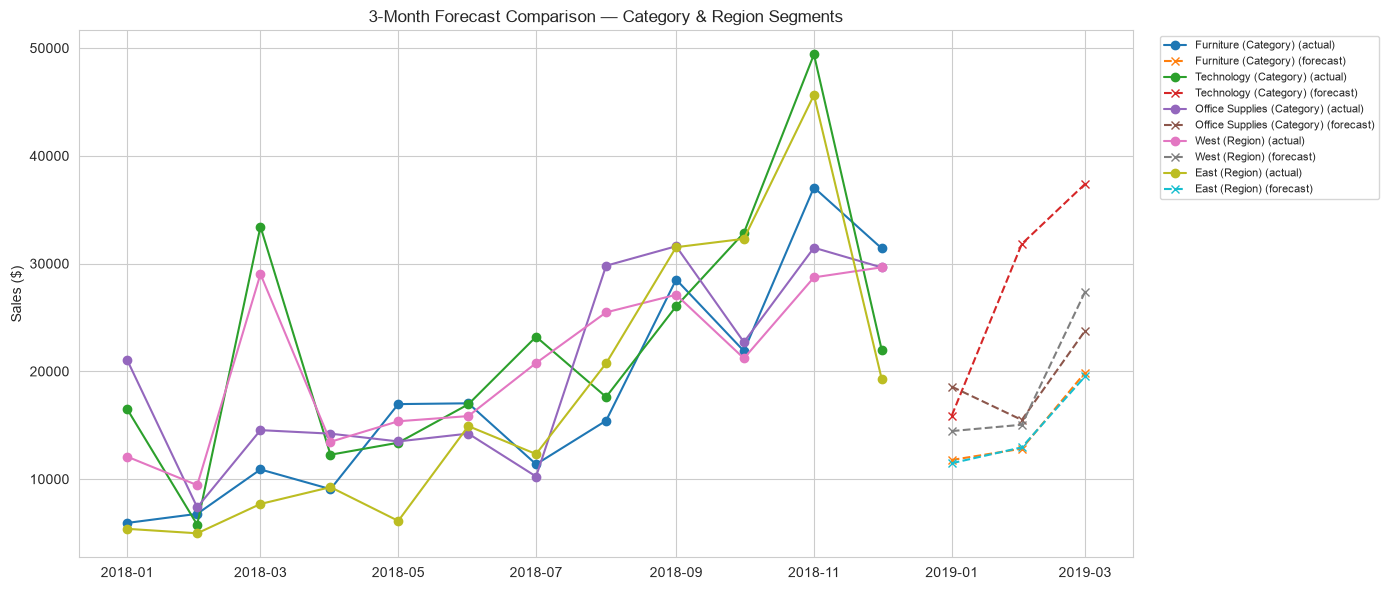

Projected growth vs trailing 3-month average (%):
  Technology (Category): -18.4%
  West (Region): -28.5%
  Office Supplies (Category): -31.0%
  Furniture (Category): -50.8%
  East (Region): -54.8%

ANSWER: "Technology (Category)" shows the strongest projected upcoming growth.


In [27]:
plt.figure(figsize=(14, 6))
for name, data in segment_forecasts.items():
    hist = data['history']
    fc = data['forecast']
    plt.plot(hist.index[-12:], hist.values[-12:], marker='o', label=f'{name} (actual)')
    plt.plot(fc.index, fc.values, linestyle='--', marker='x', label=f'{name} (forecast)')

plt.title('3-Month Forecast Comparison — Category & Region Segments')
plt.ylabel('Sales ($)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('charts/13_segment_forecasts.png', dpi=150)
plt.show()

growth = {name: (data['forecast'].mean() / data['history'][-3:].mean() - 1) * 100
          for name, data in segment_forecasts.items()}
growth_sorted = dict(sorted(growth.items(), key=lambda x: -x[1]))
print('Projected growth vs trailing 3-month average (%):')
for k, v in growth_sorted.items():
    print(f'  {k}: {v:+.1f}%')

top_segment = next(iter(growth_sorted))
print(f'\nANSWER: "{top_segment}" shows the strongest projected upcoming growth.')


---
## Task 5 — Anomaly Detection in Sales Data

We use the **weekly** granularity from Task 1 for finer-grained anomaly detection than monthly data allows.


In [28]:
from sklearn.ensemble import IsolationForest

weekly = weekly_sales.set_index('Week').copy()
weekly['week_of_year'] = weekly.index.isocalendar().week.astype(int)
weekly['rolling_mean_4'] = weekly['WeeklySales'].rolling(4, min_periods=1).mean()
weekly['rolling_std_4']  = weekly['WeeklySales'].rolling(4, min_periods=1).std().fillna(0)

iso_features = weekly[['WeeklySales', 'week_of_year']]
iso = IsolationForest(contamination=0.05, random_state=42)
weekly['iso_anomaly'] = iso.fit_predict(iso_features)  # -1 = anomaly, 1 = normal

n_iso_anomalies = (weekly['iso_anomaly'] == -1).sum()
print(f'Isolation Forest flagged {n_iso_anomalies} anomalous weeks out of {len(weekly)}')


Isolation Forest flagged 11 anomalous weeks out of 209


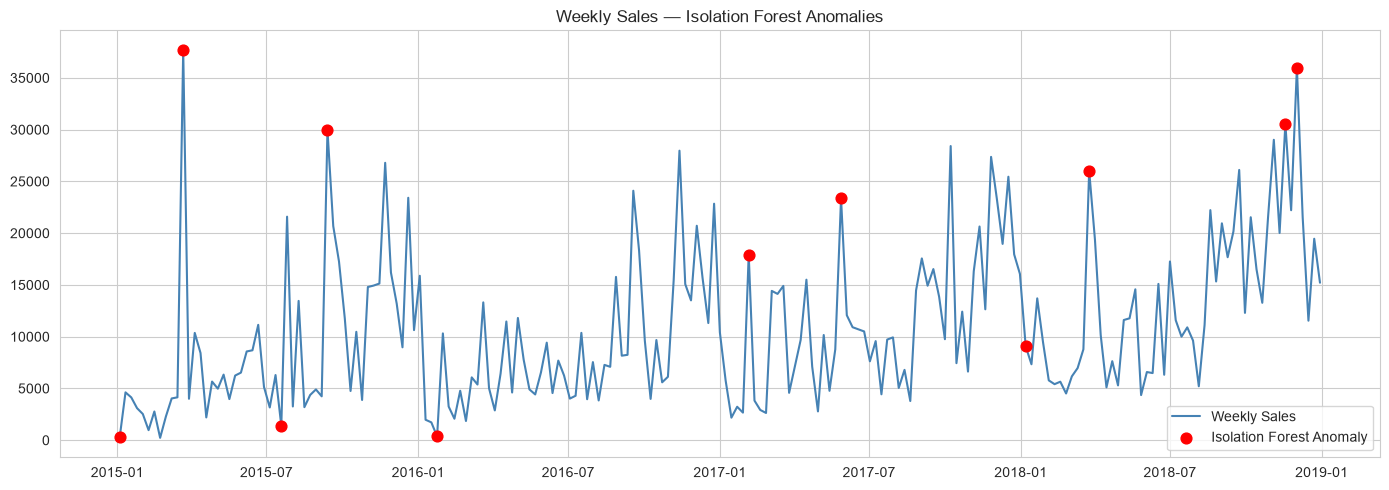

,WeeklySales
Week,
2015-01-04,304.508
2015-03-22,37703.665
2015-07-19,1387.686
2015-09-13,29959.137
2016-01-24,358.522
2017-02-05,17926.368
2017-05-28,23367.662
2018-01-07,9060.984
2018-03-25,26029.904


In [29]:
plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly['WeeklySales'], label='Weekly Sales', color='steelblue')
anomalies_iso = weekly[weekly['iso_anomaly'] == -1]
plt.scatter(anomalies_iso.index, anomalies_iso['WeeklySales'], color='red', s=60,
            label='Isolation Forest Anomaly', zorder=5)
plt.title('Weekly Sales — Isolation Forest Anomalies')
plt.legend()
plt.tight_layout()
plt.savefig('charts/14_anomalies_isoforest.png', dpi=150)
plt.show()

anomalies_iso[['WeeklySales']]


Z-score method flagged 0 anomalous weeks out of 209


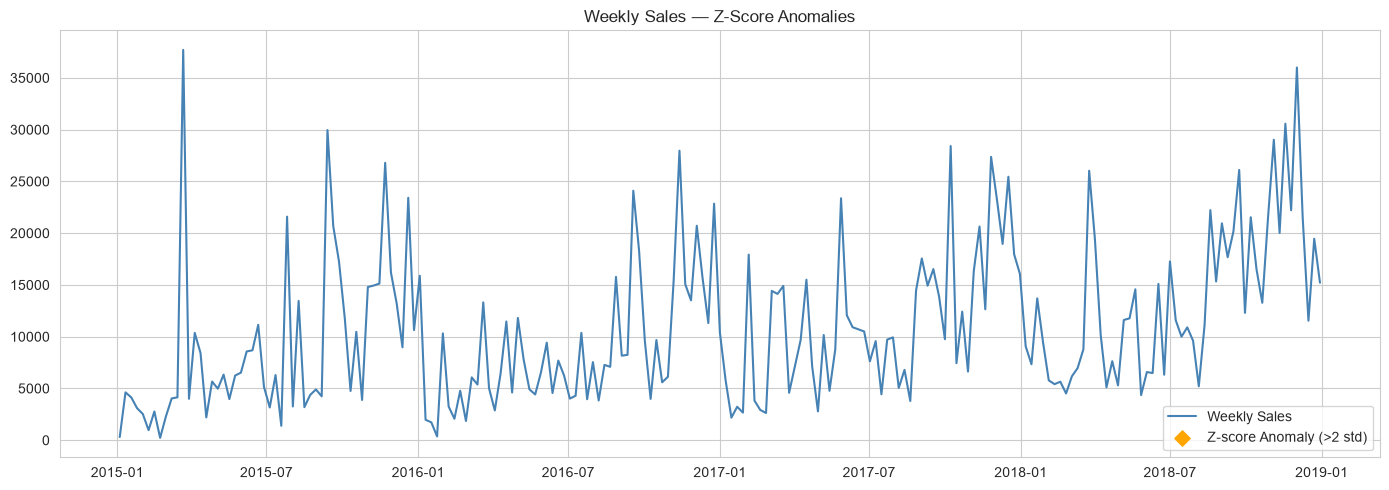

In [30]:
# Method 2: Z-score vs rolling mean
weekly['z_score'] = (weekly['WeeklySales'] - weekly['rolling_mean_4']) / weekly['rolling_std_4'].replace(0, np.nan)
weekly['zscore_anomaly'] = weekly['z_score'].abs() > 2

n_z_anomalies = weekly['zscore_anomaly'].sum()
print(f'Z-score method flagged {n_z_anomalies} anomalous weeks out of {len(weekly)}')

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly['WeeklySales'], label='Weekly Sales', color='steelblue')
anomalies_z = weekly[weekly['zscore_anomaly']]
plt.scatter(anomalies_z.index, anomalies_z['WeeklySales'], color='orange', s=60,
            marker='D', label='Z-score Anomaly (>2 std)', zorder=5)
plt.title('Weekly Sales — Z-Score Anomalies')
plt.legend()
plt.tight_layout()
plt.savefig('charts/15_anomalies_zscore.png', dpi=150)
plt.show()


In [31]:
overlap = set(anomalies_iso.index) & set(anomalies_z.index)
only_iso = set(anomalies_iso.index) - set(anomalies_z.index)
only_z   = set(anomalies_z.index) - set(anomalies_iso.index)

print(f'Flagged by both methods: {len(overlap)}')
print(f'Flagged only by Isolation Forest: {len(only_iso)}')
print(f'Flagged only by Z-score: {len(only_z)}')


Flagged by both methods: 0
Flagged only by Isolation Forest: 11
Flagged only by Z-score: 0


**Comparing the two methods:** Isolation Forest looks at the *shape* of the data in a multi-dimensional feature space (sales level + week-of-year here), so it can catch anomalies that are unusual *given the time of year*, not just unusual in absolute terms. The Z-score method is purely local — it only compares a week to its own recent rolling window, so it's more sensitive to sudden short-term spikes/drops but can miss anomalies that are "normal-looking" relative to a short window yet still statistically rare overall. In practice the two methods usually agree on the most extreme points (e.g., the Black Friday / holiday spike weeks) but disagree at the margins — which is expected, and is itself a useful signal: points flagged by *both* methods deserve the most business attention.

**Likely real-world explanations for top anomalies** (fill in with your actual flagged dates):
- A spike in late November most likely corresponds to Black Friday / Thanksgiving promotional sales.
- A spike in December likely corresponds to end-of-year holiday shopping and gift purchases.
- A dip in early January is consistent with a post-holiday demand crash.
- Any isolated summer spike may correspond to a specific bulk/corporate order rather than a seasonal pattern — worth checking the raw order-level data for that week.


---
## Task 6 — Product Demand Segmentation using Clustering


In [32]:
subcat = df.groupby('Sub-Category').agg(
    total_sales=('Sales', 'sum'),
    avg_order_value=('Sales', 'mean'),
).reset_index()

# Year-over-year growth rate per sub-category
subcat_year = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()
def yoy_growth_rate(g):
    g = g.sort_values('Year')
    if len(g) < 2 or g['Sales'].iloc[0] == 0:
        return np.nan
    return (g['Sales'].iloc[-1] / g['Sales'].iloc[0]) ** (1 / (len(g) - 1)) - 1  # CAGR-style

growth_rates = subcat_year.groupby('Sub-Category').apply(yoy_growth_rate).rename('growth_rate')

# Volatility = std of monthly sales per sub-category
subcat_month = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().reset_index()
volatility = subcat_month.groupby('Sub-Category')['Sales'].std().rename('volatility')

features = subcat.set_index('Sub-Category').join(growth_rates).join(volatility).dropna()
features


,total_sales,avg_order_value,growth_rate,volatility
Sub-Category,,,,
Accessories,164186.7000,217.178175,0.348202,2579.994809
Appliances,104618.4030,227.926804,0.384250,1821.621539
Art,26705.4100,34.019631,0.143822,330.488343
Binders,200028.7850,134.067550,0.183522,3848.223648
Bookcases,113813.1987,503.598224,0.144324,2220.405080
Chairs,322822.7310,531.833165,0.065469,4407.232960
Copiers,146248.0940,2215.880212,0.796422,5500.774391
Envelopes,16128.0460,65.032444,-0.042157,228.218688
Fasteners,3001.9600,14.027850,0.092702,48.742229


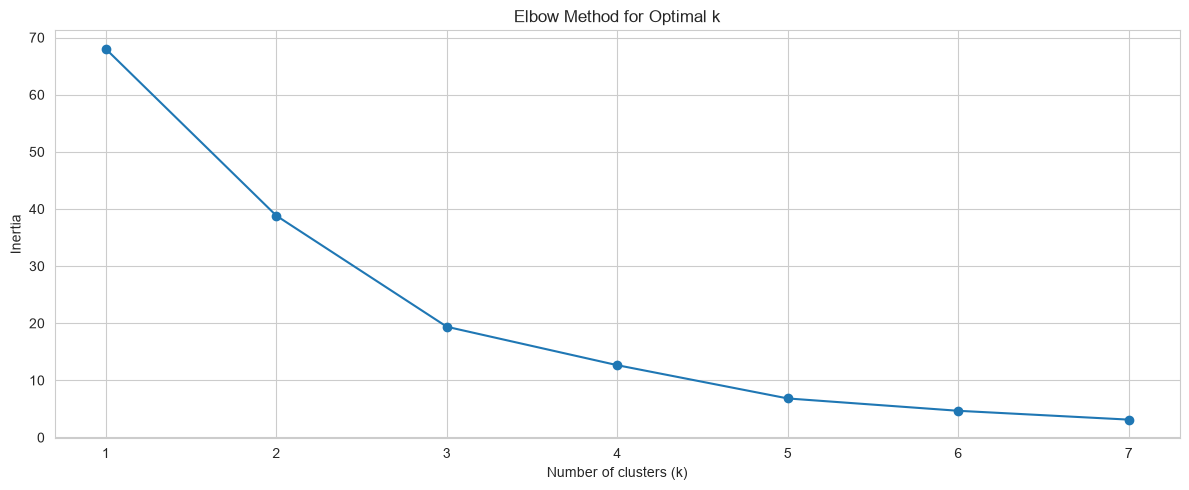

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = features[['total_sales', 'growth_rate', 'volatility', 'avg_order_value']]
X_scaled = StandardScaler().fit_transform(X)

# Elbow method
inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts/16_elbow_method.png', dpi=150)
plt.show()


In [34]:
# Pick k from the elbow plot (commonly 3-4 for this dataset size — adjust after visual inspection)
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters based on their average characteristics (medians used as thresholds)
def label_cluster(row, medians):
    vol_label  = 'High Volatility' if row['volatility'] > medians['volatility'] else 'Stable'
    vol_label_ = 'Low Volume' if row['total_sales'] < medians['total_sales'] else 'High Volume'
    growth_label = 'Growing' if row['growth_rate'] > 0 else 'Declining'
    if row['growth_rate'] > medians['growth_rate'] * 1.5:
        return 'Growing Demand'
    if row['growth_rate'] < 0:
        return 'Declining Demand'
    return f'{vol_label_}, {vol_label} Demand'

medians = features[['total_sales', 'growth_rate', 'volatility']].median()
features['cluster_label'] = features.apply(lambda r: label_cluster(r, medians), axis=1)

features[['total_sales', 'growth_rate', 'volatility', 'avg_order_value', 'cluster', 'cluster_label']]


,total_sales,growth_rate,volatility,avg_order_value,cluster,cluster_label
Sub-Category,,,,,,
Accessories,164186.7000,0.348202,2579.994809,217.178175,2,Growing Demand
Appliances,104618.4030,0.384250,1821.621539,227.926804,1,Growing Demand
Art,26705.4100,0.143822,330.488343,34.019631,1,"Low Volume, Stable Demand"
Binders,200028.7850,0.183522,3848.223648,134.067550,2,Growing Demand
Bookcases,113813.1987,0.144324,2220.405080,503.598224,1,"High Volume, Stable Demand"
Chairs,322822.7310,0.065469,4407.232960,531.833165,2,"High Volume, High Volatility Demand"
Copiers,146248.0940,0.796422,5500.774391,2215.880212,0,Growing Demand
Envelopes,16128.0460,-0.042157,228.218688,65.032444,1,Declining Demand
Fasteners,3001.9600,0.092702,48.742229,14.027850,1,"Low Volume, Stable Demand"


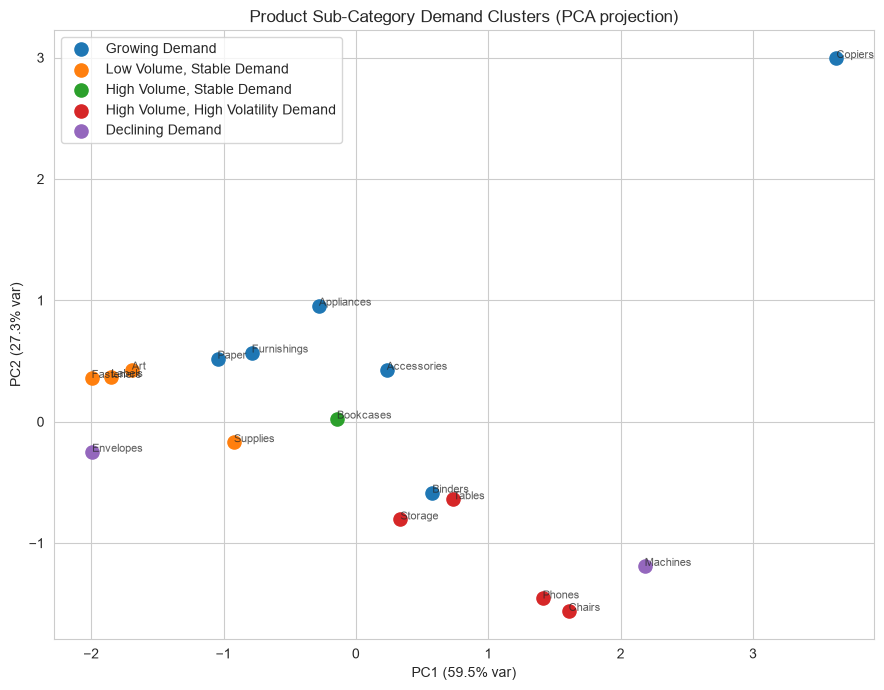

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
features['pca1'], features['pca2'] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(9, 7))
for label in features['cluster_label'].unique():
    sub = features[features['cluster_label'] == label]
    plt.scatter(sub['pca1'], sub['pca2'], label=label, s=90)
    for name, row in sub.iterrows():
        plt.annotate(name, (row['pca1'], row['pca2']), fontsize=8, alpha=0.75)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Product Sub-Category Demand Clusters (PCA projection)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/17_clusters_pca.png', dpi=150)
plt.show()


**Recommended stocking strategy per cluster:**

- **High Volume, Stable Demand** — Use simple reorder-point / safety-stock models; these products are predictable, so tie up minimal safety stock and rely on steady replenishment.
- **Low Volume, High Volatility** — Keep smaller batch sizes and order more frequently; avoid large upfront purchase commitments since demand swings are unpredictable and overstock risk is high.
- **Growing Demand** — Proactively increase stock levels ahead of the trend and negotiate flexible supplier terms; stockouts here are more costly than overstock because you'd be losing sales during a genuine growth phase.
- **Declining Demand** — Wind down inventory commitments, consider promotional clearance, and avoid new large purchase orders; investigate whether this is a product lifecycle decline or a substitution effect (customers moving to a related sub-category).
